# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** ___________________________  |  **Date:** _______________

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [1]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Also set sns theme to 'whitegrid' and default figure size to (10,5)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Task 2 — Load & Inspect Data

In [2]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

# Load the data
df = pd.read_csv(url, sep='\s+', names=col_names, na_values='?')

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\DELL\AppData\Local\Temp\ipykernel_8344\4147642937.py:12: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep='\s+', names=col_names, na_values='?')


In [3]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [22]:
# TODO: Print df.describe() to view summary statistics
df.describe()

,mpg,displacement,horsepower,weight,acceleration
count,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,194.411990,104.469388,2977.584184,15.541327
std,7.805007,104.644004,38.491160,849.402560,2.758864
min,9.000000,68.000000,46.000000,1613.000000,8.000000
25%,17.000000,105.000000,75.000000,2225.250000,13.775000
50%,22.750000,151.000000,93.500000,2803.500000,15.500000
75%,29.000000,275.750000,126.000000,3614.750000,17.025000
max,46.600000,455.000000,230.000000,5140.000000,24.800000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** 398 rows and 9 columns

**Q2.** Which column contains missing values and how many?  
**Answer:** horsepower column has 6 missing values

## Task 3 — Pre-Processing

In [4]:
# TODO: Check and print missing values per column
# Then drop all rows that contain NaN values (they are < 2% of data)
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with NaN
df = df.dropna()
print(f"\nAfter dropping NaN: {df.shape[0]} rows")

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

After dropping NaN: 392 rows


In [5]:
# TODO: Check for and remove duplicate rows
print(f"Duplicates before: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape[0]} rows")

Duplicates before: 0
After removing duplicates: 392 rows


In [6]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
# 3. Strip & lowercase 'car_name'
df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')

df['origin'] = df['origin'].map({1: 'usa', 2: 'europe', 3: 'japan'})

df['car_name'] = df['car_name'].str.strip().str.lower()

In [7]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders', 'origin', 'model_year']   # fill in
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']   # fill in

## Task 4 — Feature Engineering

In [8]:
# TODO: Create 'mpg_level' column using pd.cut()
# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'
bins = [0, 17, 29, df['mpg'].max()]
labels = ['low', 'medium', 'high']
df['mpg_level'] = pd.cut(df['mpg'], bins=bins, labels=labels, right=False)

In [9]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'
df['car_company'] = df['car_name'].str.split().str[0]

## Task 5 — Categorical EDA

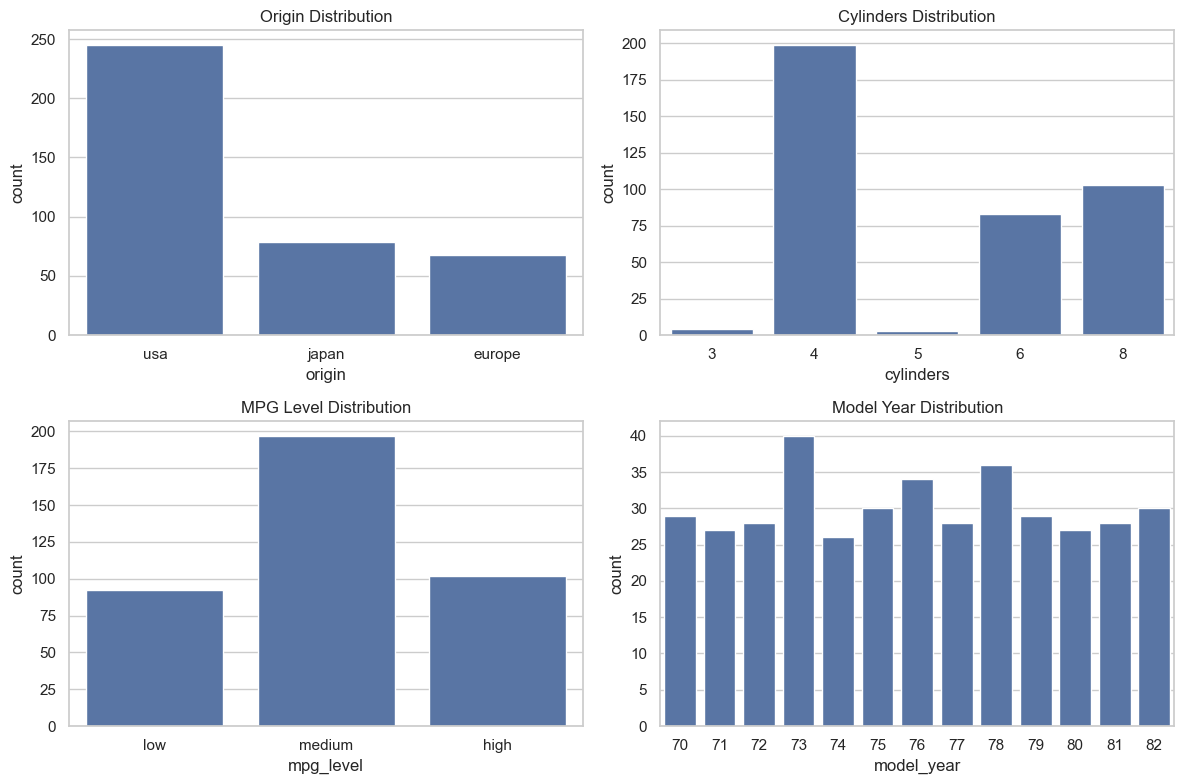

In [10]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year
# Arrange them in a 2×2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=df, x='origin', ax=axes[0,0])
axes[0,0].set_title('Origin Distribution')

sns.countplot(data=df, x='cylinders', ax=axes[0,1])
axes[0,1].set_title('Cylinders Distribution')

sns.countplot(data=df, x='mpg_level', ax=axes[1,0])
axes[1,0].set_title('MPG Level Distribution')

sns.countplot(data=df, x='model_year', ax=axes[1,1])
axes[1,1].set_title('Model Year Distribution')

plt.tight_layout()
plt.show()

In [11]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level
for col in ['origin', 'cylinders', 'mpg_level']:
    dominant = df[col].value_counts().idxmax()
    proportion = (df[col].value_counts().max() / len(df)) * 100
    print(f"{col}: {dominant} is {proportion:.1f}%")

origin: usa is 62.5%
cylinders: 4 is 50.8%
mpg_level: medium is 50.3%


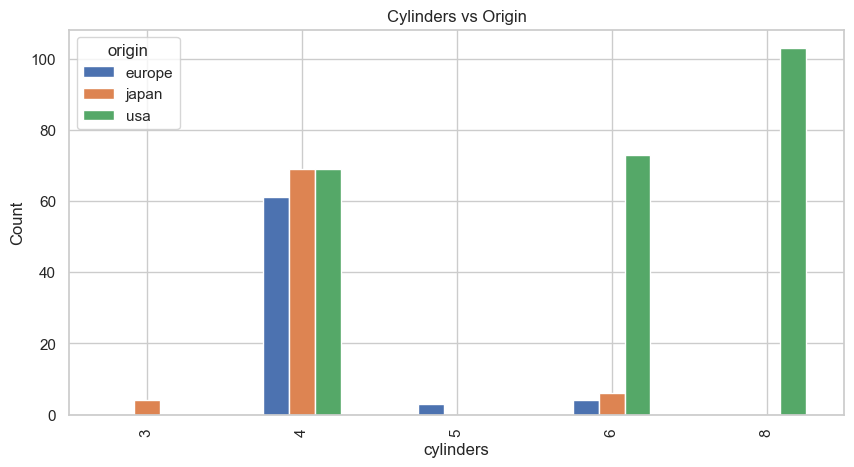

In [12]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart
crosstab = pd.crosstab(df['cylinders'], df['origin'])
crosstab.plot(kind='bar', figsize=(10,5))
plt.title('Cylinders vs Origin')
plt.ylabel('Count')
plt.show()

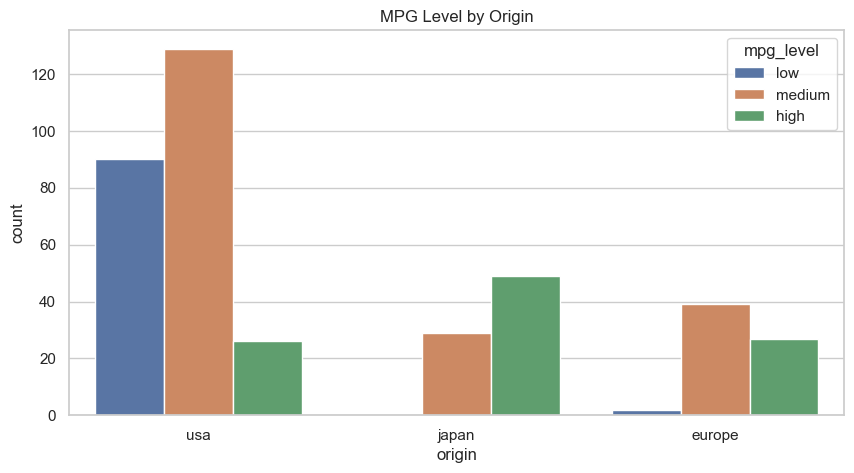

In [13]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')
sns.countplot(data=df, x='origin', hue='mpg_level')
plt.title('MPG Level by Origin')
plt.show()

**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** japan

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** 4 cylinders, 50.8%

## Task 6 — Numerical EDA

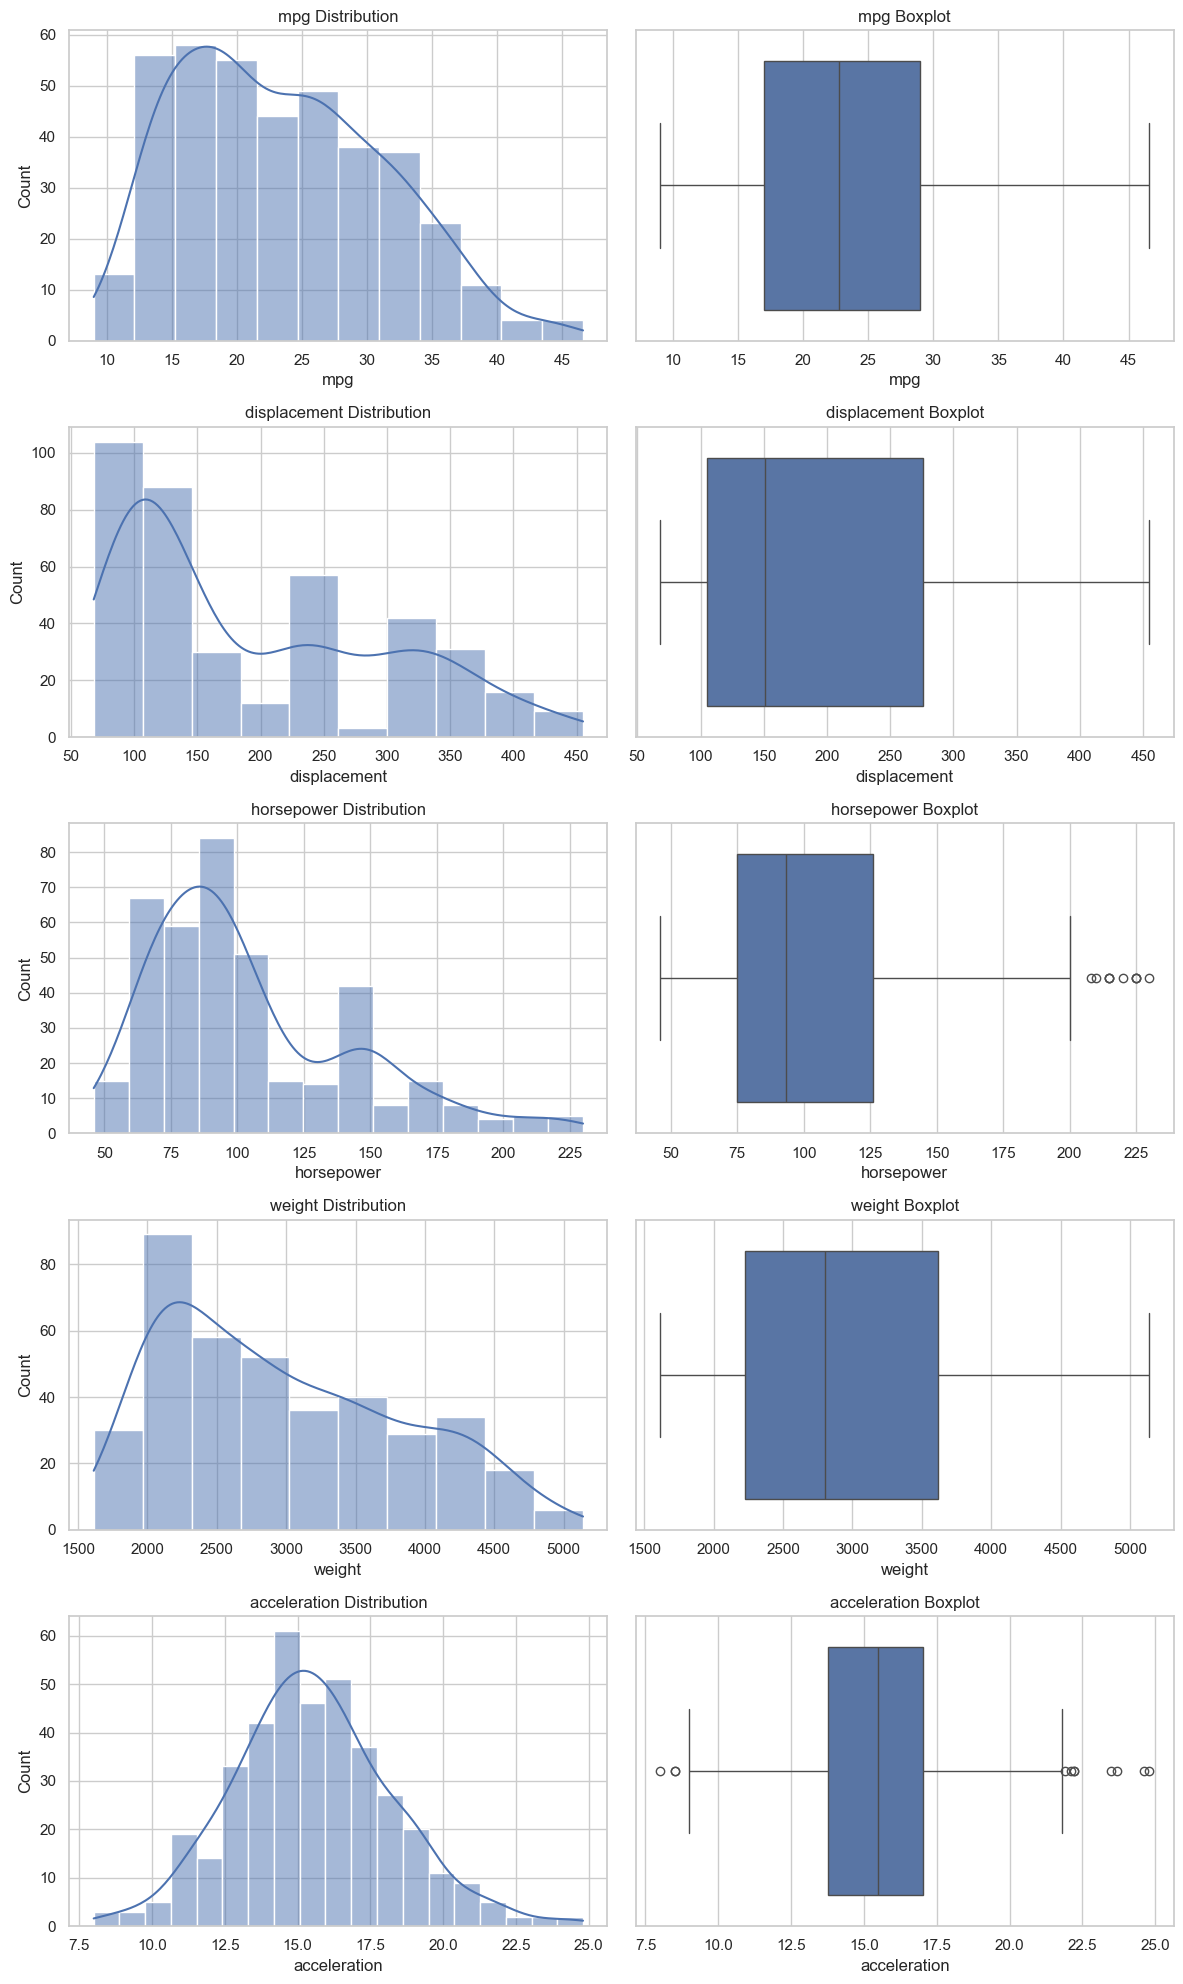

In [14]:
# TODO: For each numerical column plot:
#   (a) Histogram + KDE  (b) Boxplot
# Arrange in a grid (n_cols rows × 2 columns)
n_cols = len(num_cols)
fig, axes = plt.subplots(n_cols, 2, figsize=(12, 4*n_cols))

for i, col in enumerate(num_cols):
    # Histogram + KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} Distribution')
    
    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[i,1])
    axes[i,1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

In [15]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Then print the outlier count for each numerical column

def tukey_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers

for col in num_cols:
    outliers = tukey_outliers(df[col])
    print(f"{col}: {len(outliers)} outliers")

mpg: 0 outliers
displacement: 0 outliers
horsepower: 10 outliers
weight: 0 outliers
acceleration: 11 outliers


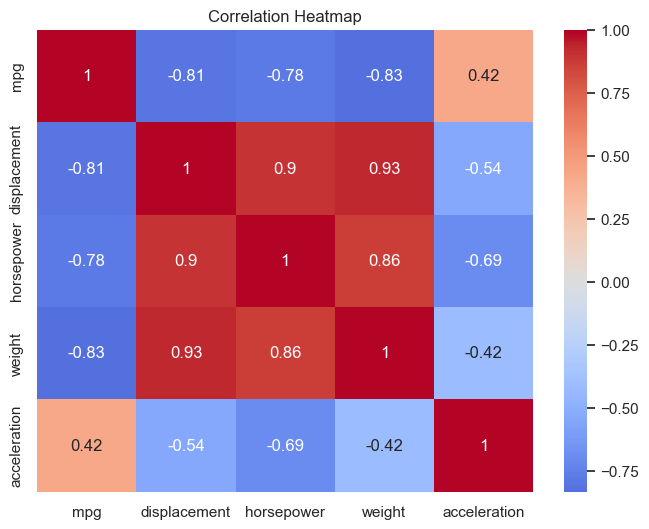

In [16]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

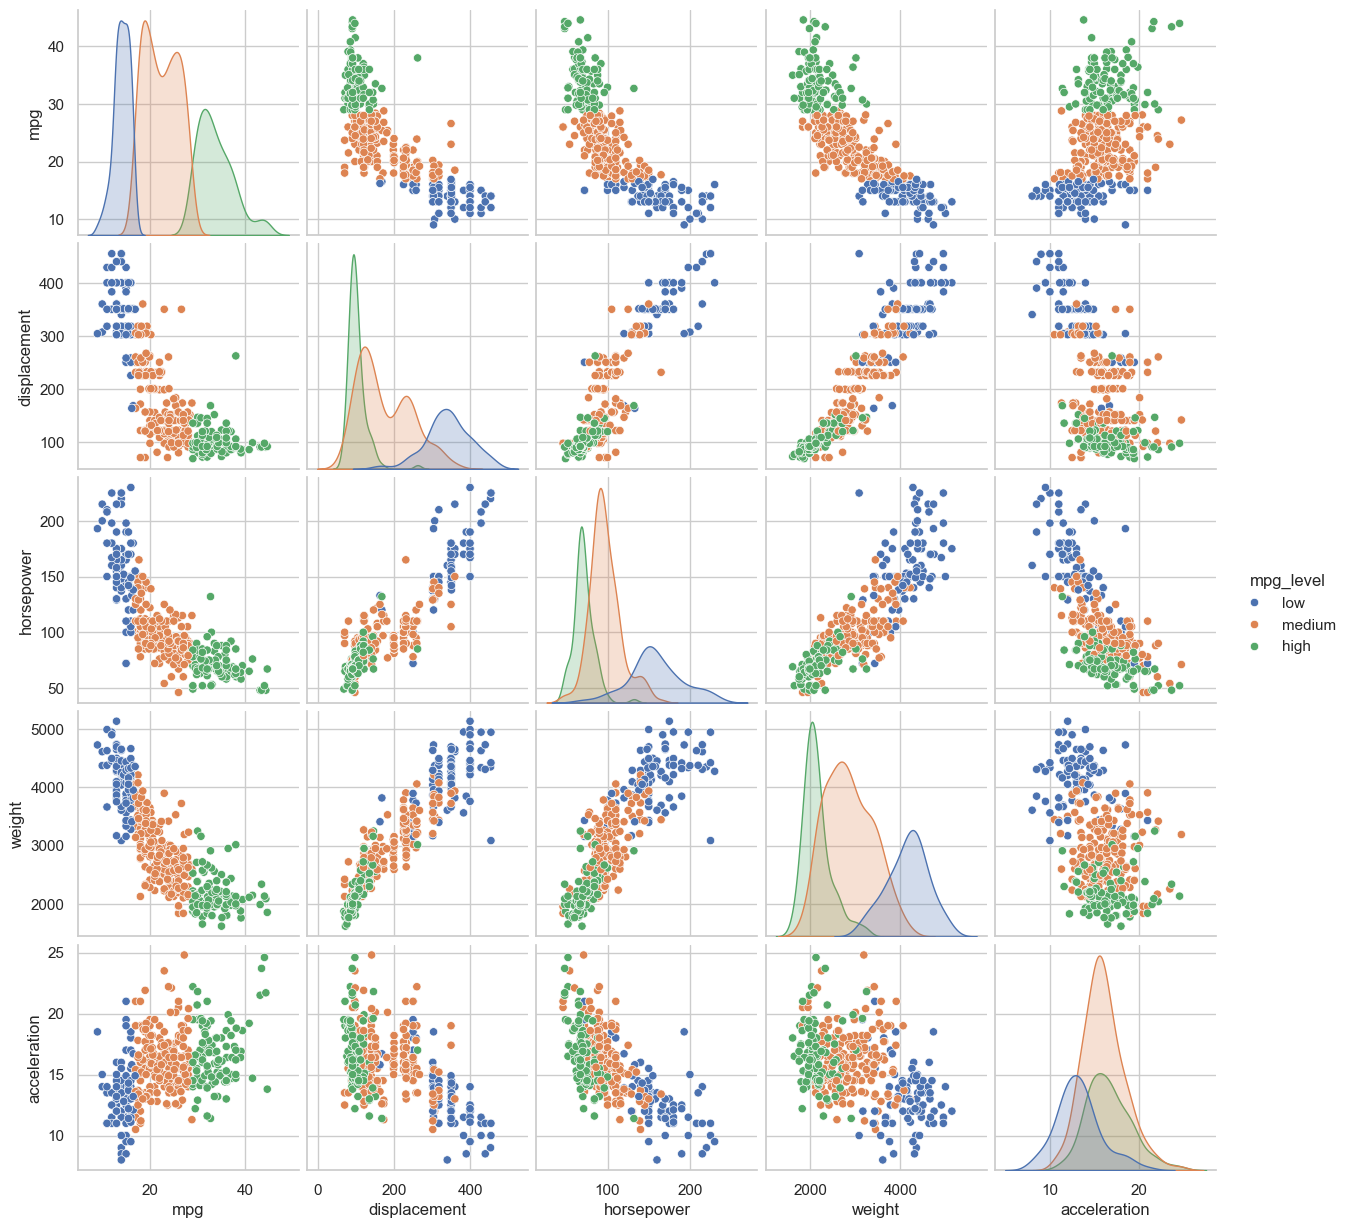

In [18]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level
sns.pairplot(df[num_cols + ['mpg_level']], hue='mpg_level', diag_kind='kde')
plt.show()

**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** weight and displacement

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** Roughly symmetric but with outliers, not perfectly Gaussian.

## Task 7 — Numerical vs Categorical

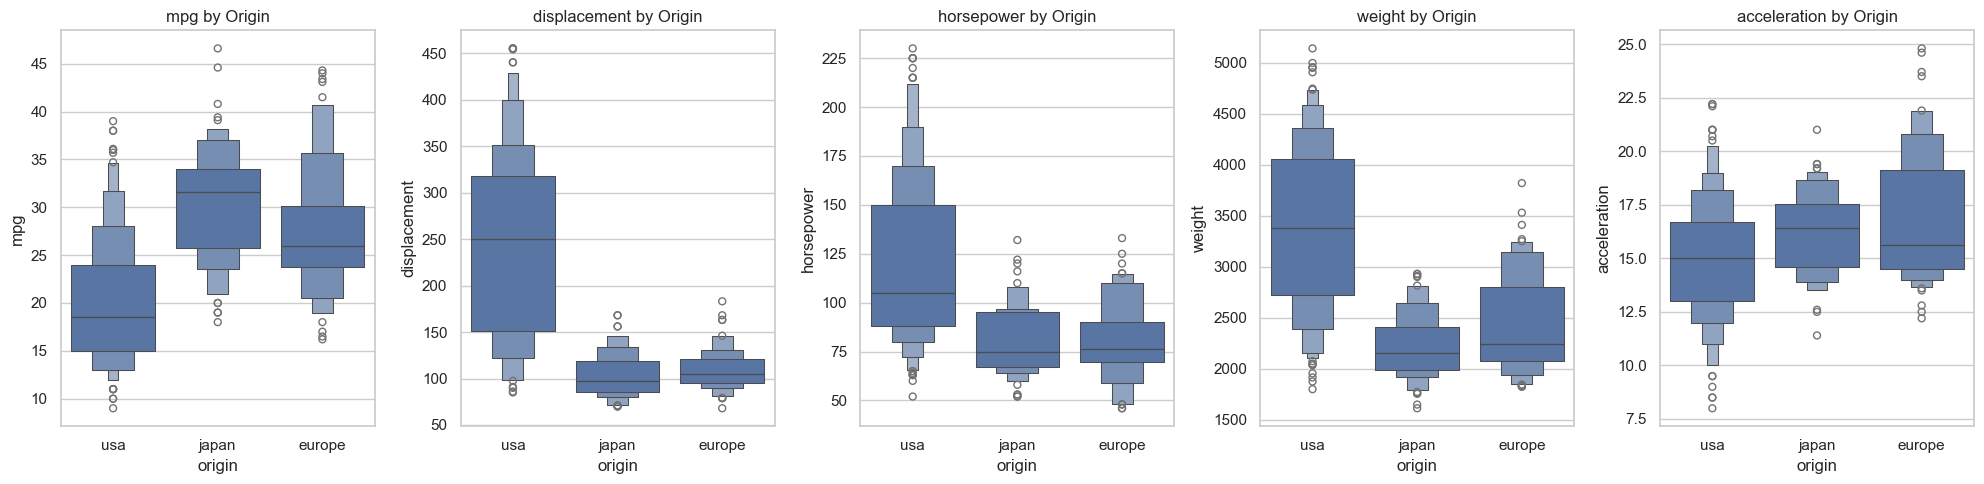

In [23]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(num_cols):
    sns.boxenplot(data=df, x='origin', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Origin')

plt.tight_layout()
plt.show()

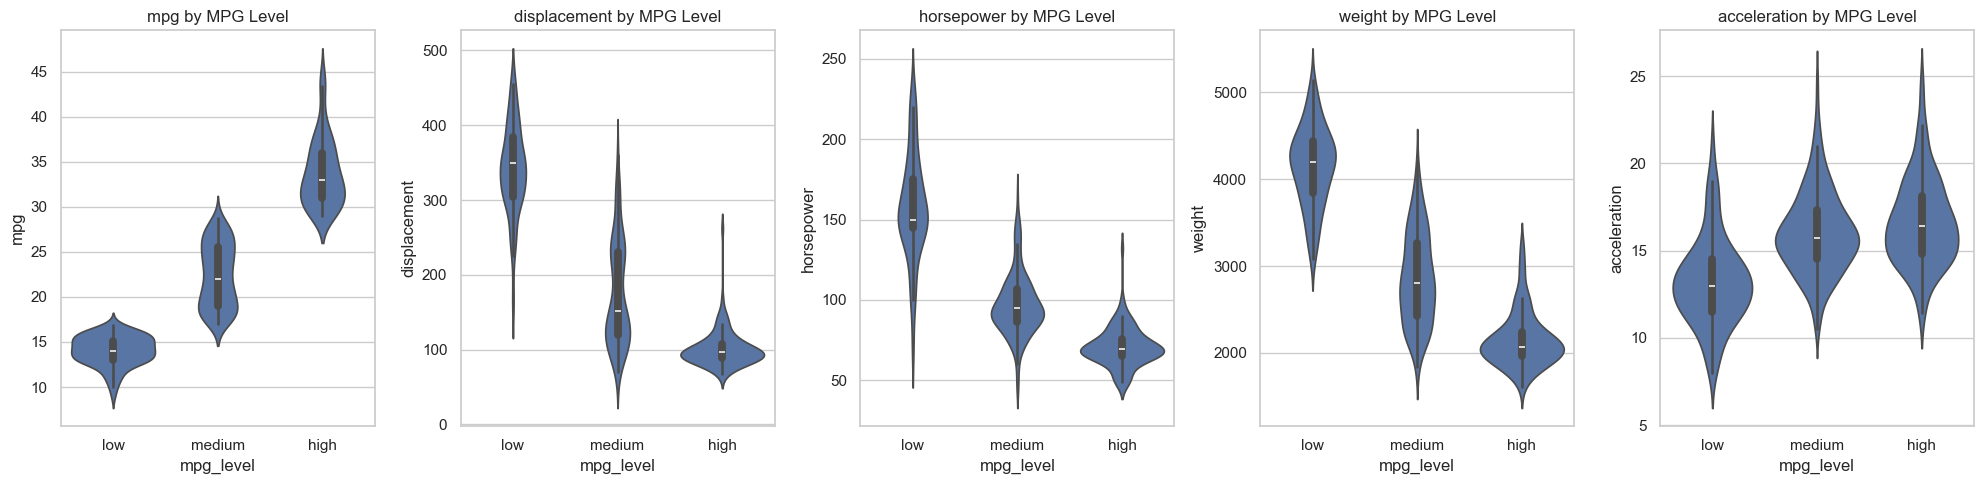

In [20]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(num_cols):
    sns.violinplot(data=df, x='mpg_level', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by MPG Level')

plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8344\892836217.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_mpg = df.groupby('model_year')['mpg'].mean()


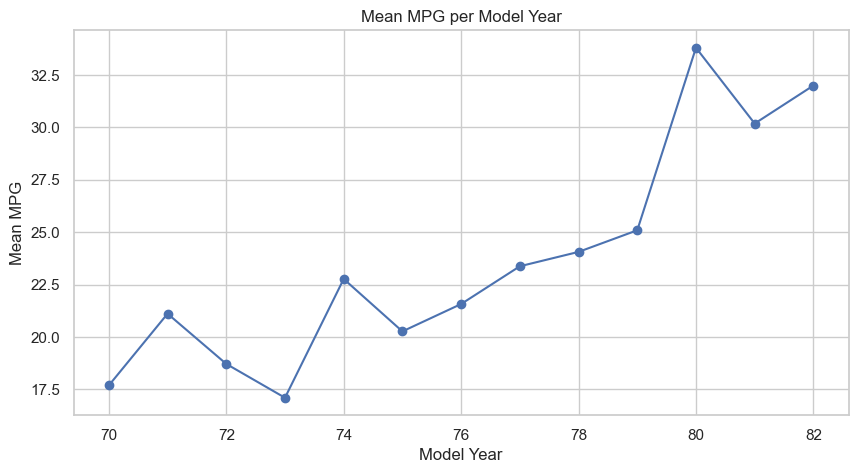

In [21]:
# TODO: Plot a line chart showing mean mpg per model_year
mean_mpg = df.groupby('model_year')['mpg'].mean()
plt.figure(figsize=(10,5))
plt.plot(mean_mpg.index, mean_mpg.values, marker='o')
plt.title('Mean MPG per Model Year')
plt.xlabel('Model Year')
plt.ylabel('Mean MPG')
plt.grid(True)
plt.show()

**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** usa

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** MPG increases over time as cars become more fuel efficient.

## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | negative | strong |
| horsepower | negative | strong |
| weight | negative | strong |
| acceleration | positive | weak |
| cylinders | negative | moderate |
| origin | varies | japan highest mpg |
| model_year | positive | moderate |